In [8]:
from pathlib import Path
import dask.dataframe as dd
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm

In [9]:
YEAR = 2021
DF_FILEPATH = Path(F"../data/silver/ghana-{YEAR}-df.parquet")
RAW_XY_FOLDERPATH = Path(F'../data/silver/Xy-{YEAR}')

# Load data

In [10]:
df = pd.read_parquet(DF_FILEPATH)
df.head(1)

,lon,lat,red,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,...,ndwi_11x11_var,tci_11x11_median,ndvi_11x11_median,evi_11x11_median,evi2_11x11_median,ndre_b5_11x11_median,ndre_b6_11x11_median,ndre_b7_11x11_median,gndvi_11x11_median,ndwi_11x11_median
1,-0.273906,11.170402,0.121569,0.121569,0.109804,0.129412,0.007843,0.117647,0.109804,0.129412,...,-0.230769,0.036183,0.25,0.083682,-0.099099,0.106383,0.050505,0.019608,0.132626,-0.099099


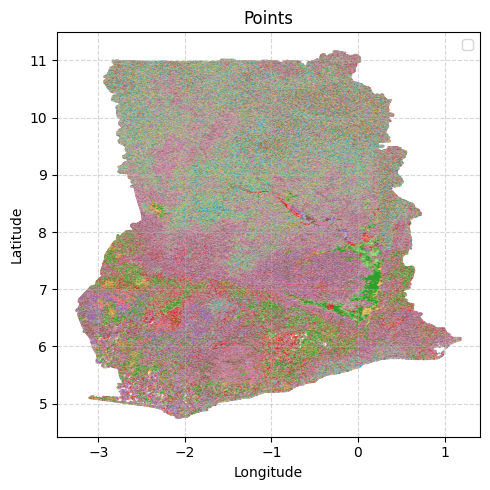

In [11]:
# Plot the data
plt.figure(figsize=(5, 5))
sns.scatterplot(data=df, x='lon', y='lat', hue='red', palette='tab20', s=1, alpha=0.5, edgecolor=None)

plt.title('Points')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend([])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# Spatially-split each region (train:val:test)

In [12]:
def add_folds(df, n_folds: int = 1_000):
    """Create n_folds spatially, where each region has its own folds (no overlap)."""

    df = df.copy()
    
    # Initialize the column safely to avoid errors before assignment
    df['fold_idx'] = -1 

    kmeans = KMeans(n_clusters=n_folds, random_state=42, n_init=10)
    
    # Initialize a running offset
    current_fold_offset = 0
    
    # Compute spatial folds
    for region in tqdm(df.region.dropna().unique()):
        mask = df.region == region
        coords = df.loc[mask, ['lat', 'lon']]
        
        # Fallback just in case a region has fewer points than n_folds
        if len(coords) < n_folds:
            actual_folds = len(coords)
            temp_kmeans = KMeans(n_clusters=actual_folds, random_state=42, n_init=10)
            fold_idxs = temp_kmeans.fit_predict(coords)
        else:
            actual_folds = n_folds
            fold_idxs = kmeans.fit_predict(coords)
        
        # Add the offset to ensure uniqueness across regions
        df.loc[mask, 'fold_idx'] = fold_idxs + current_fold_offset
        
        # Increment the offset for the next region
        current_fold_offset += actual_folds

    # Cast to integer at the end
    df['fold_idx'] = df['fold_idx'].astype(int)
    
    return df
    
df = add_folds(df)

100%|██████████████████████████████████████████████████████████████████████| 16/16 [09:20<00:00, 35.00s/it]


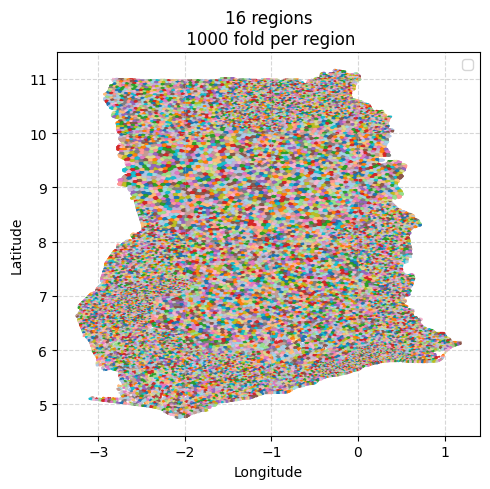

In [13]:
# Plot the folds
plt.figure(figsize=(5, 5))
sns.scatterplot(data=df, x='lon', y='lat', hue='fold_idx', palette='tab20', s=1, alpha=0.5, edgecolor=None)

n_fold_per_region = int(df.groupby('region').fold_idx.nunique().min())
plt.title(f'{df.region.nunique()} regions\n {n_fold_per_region} fold per region')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend([])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

In [14]:
import pandas as pd

RAW_XY_FOLDERPATH.mkdir(exist_ok=True)

Xy = df.drop(columns=['fold_idx', 'lon', 'lat'])
metadata_df = df[['lon', 'lat', 'fold_idx']]
    
# Dump to disk 
Xy.to_parquet(RAW_XY_FOLDERPATH / "Xy.parquet")
metadata_df.to_parquet(RAW_XY_FOLDERPATH / "metadata_df.parquet")